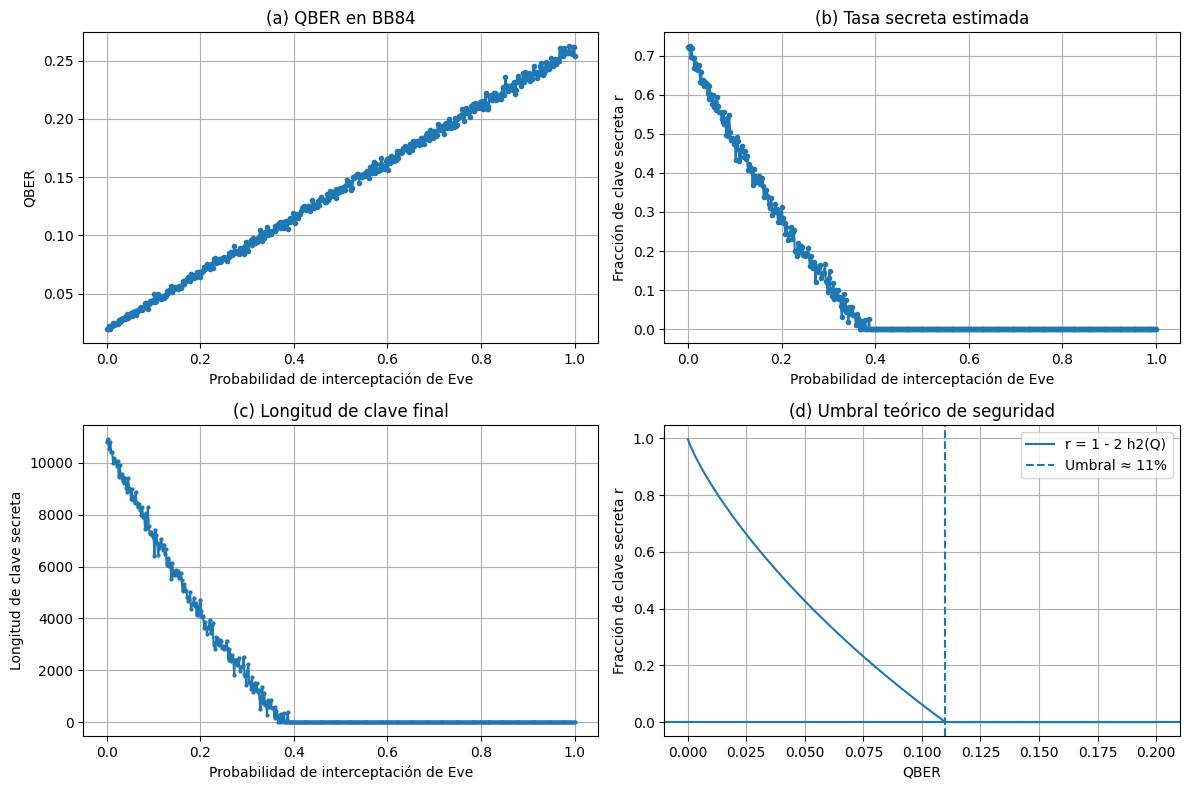

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def binary_entropy(q):
    if q <= 0 or q >= 1:
        return 0.0
    return -q * np.log2(q) - (1 - q) * np.log2(1 - q)

def bb84_simulation(n=20000, eve_prob=0.0, noise_prob=0.0):
    # Alice
    alice_bits = np.random.randint(0, 2, n)
    alice_bases = np.random.randint(0, 2, n)   # 0 = Z, 1 = X

    # Bob
    bob_bases = np.random.randint(0, 2, n)

    # Estado transmitido inicialmente
    transmitted_bits = alice_bits.copy()
    transmitted_bases = alice_bases.copy()

    # Eve intercept-resend
    eve_attacks = np.random.rand(n) < eve_prob
    eve_bases = np.random.randint(0, 2, n)

    for i in range(n):
        if eve_attacks[i]:
            if eve_bases[i] == transmitted_bases[i]:
                eve_bit = transmitted_bits[i]
            else:
                eve_bit = np.random.randint(0, 2)

            transmitted_bits[i] = eve_bit
            transmitted_bases[i] = eve_bases[i]

    # Bob mide
    bob_bits = np.zeros(n, dtype=int)
    for i in range(n):
        if bob_bases[i] == transmitted_bases[i]:
            bob_bits[i] = transmitted_bits[i]
        else:
            bob_bits[i] = np.random.randint(0, 2)

    # Ruido del canal
    noise = np.random.rand(n) < noise_prob
    bob_bits[noise] = 1 - bob_bits[noise]

    # Sifting
    sift = (alice_bases == bob_bases)
    alice_key = alice_bits[sift]
    bob_key = bob_bits[sift]

    sifted_length = len(alice_key)

    if sifted_length == 0:
        return 0.0, 0, 0.0, 0

    qber = np.mean(alice_key != bob_key)

    r = max(0.0, 1 - 2 * binary_entropy(qber))

    secret_length = int(r * sifted_length)

    return qber, sifted_length, r, secret_length


# Barrido en probabilidad de espionaje
eve_probs = np.linspace(0, 1, 500)
qbers = []
secret_fractions = []
secret_lengths = []

for p in eve_probs:
    qber, sifted_length, r, secret_length = bb84_simulation(
        n=30000,
        eve_prob=p,
        noise_prob=0.02
    )
    qbers.append(qber)
    secret_fractions.append(r)
    secret_lengths.append(secret_length)

# Curva teórica r(Q)
q_vals = np.linspace(0.0001, 0.2, 500)
secret_rate = [max(0, 1 - 2 * binary_entropy(q)) for q in q_vals]

q_threshold = 0.11

# ---- FIGURA CON SUBPLOTS ----
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# (a) QBER
axs[0,0].plot(eve_probs, qbers, marker='o', markersize=3)
axs[0,0].set_xlabel("Probabilidad de interceptación de Eve")
axs[0,0].set_ylabel("QBER")
axs[0,0].set_title("(a) QBER en BB84")
axs[0,0].grid(True)

# (b) Fracción secreta
axs[0,1].plot(eve_probs, secret_fractions, marker='o', markersize=3)
axs[0,1].set_xlabel("Probabilidad de interceptación de Eve")
axs[0,1].set_ylabel("Fracción de clave secreta r")
axs[0,1].set_title("(b) Tasa secreta estimada")
axs[0,1].grid(True)

# (c) Longitud de clave
axs[1,0].plot(eve_probs, secret_lengths, marker='o',markersize=2)
axs[1,0].set_xlabel("Probabilidad de interceptación de Eve")
axs[1,0].set_ylabel("Longitud de clave secreta")
axs[1,0].set_title("(c) Longitud de clave final")
axs[1,0].grid(True)

# (d) Umbral teórico
axs[1,1].plot(q_vals, secret_rate, label="r = 1 - 2 h2(Q)")
axs[1,1].axvline(q_threshold, linestyle="--", label="Umbral ≈ 11%")
axs[1,1].axhline(0)
axs[1,1].set_xlabel("QBER")
axs[1,1].set_ylabel("Fracción de clave secreta r")
axs[1,1].set_title("(d) Umbral teórico de seguridad")
axs[1,1].legend()
axs[1,1].grid(True)

plt.tight_layout()
plt.show()